In [1]:
# =====================================================================
# CELL 1: IMPORTS AND SETUP
# =====================================================================

import os
os.environ["CBEAM_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# JAX versions
import jax, diffrax
print(f"JAX: {jax.__version__}")
print(f"Diffrax: {diffrax.__version__}")
print(f"NumPy: {np.__version__}")

JAX: 0.10.1
Diffrax: 0.7.2
NumPy: 2.4.6


In [2]:
# =====================================================================
# CELL 2: IMPORT BATCH PIPELINE
# =====================================================================

from batch_propagation_pipeline import (
    get_simulation_parameters,
    build_and_characterize_lantern,
    get_waveguide_properties,
    IncidentFieldGenerator,
    project_field_to_modal_basis,
    BatchPropagationPipeline,
    visualize_batch_output,
    visualize_batch_hex_grid_signals,
    batch_statistics
)

print("Batch pipeline imported successfully")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/dev/cbeam/src/cbeam/FEval`


Batch pipeline imported successfully


In [3]:
# =====================================================================
# CELL 3: INITIALIZE SYSTEM PARAMETERS
# =====================================================================

p = get_simulation_parameters()

print("\n" + "="*60)
print("SIMULATION PARAMETERS")
print("="*60)
print(f"Wavelength: {p['wl']} μm")
print(f"Lantern length: {p['z_ex']} μm")
print(f"Cladding radius: {p['rclad']} μm")
print(f"Jacket radius: {p['rjack']} μm")
print(f"Core radius: {p['rcore']:.3f} μm")
print(f"Taper factor: {p['taper_factor']}")
print(f"Available influence function: {p['ifunc_file']}")


SIMULATION PARAMETERS
Wavelength: 0.8 μm
Lantern length: 100000 μm
Cladding radius: 9.0 μm
Jacket radius: 27 μm
Core radius: 0.150 μm
Taper factor: 12.0
Available influence function: /raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits


In [4]:
# =====================================================================
# CELL 4: LOAD INFLUENCE FUNCTION AND PROPAGATOR
# =====================================================================

import specula

print("Initializing SPECULA GPU...")
specula.init(0)
from specula.data_objects.ifunc import IFunc

print("Loading influence function...")
# UPDATE THIS LINE TO EXPLICITLY PASS THE DEVICE INDEX:
print(p["ifunc_file"])
ifunc = IFunc.restore(p["ifunc_file"]) 

print(f"  Influence function modes: {len(ifunc.influence_function)}")

print("\nBuilding photonic lantern propagator...")
prop12 = build_and_characterize_lantern(p)

print(f"  Propagator type: {type(prop12).__name__}")
print(f"  Total z range: {prop12.zs[0]:.0f} to {prop12.zs[-1]:.0f} μm")

Initializing SPECULA GPU...


2026-05-30 19:03:09,925 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-05-30 19:03:10,343 [INFO]: [specula]: Default device is GPU number 0


Loading influence function...
/raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits
  Influence function modes: 10

Building photonic lantern propagator...


  Propagator type: ChainPropagator
  Total z range: 0 to 100000 μm


In [5]:
# =====================================================================
# CELL 5: CREATE BATCH PROPAGATION PIPELINE
# =====================================================================

print("Creating batch propagation pipeline...\n")
pipeline = BatchPropagationPipeline(prop12, p, ifunc)

print("Waveguide Properties:")
print(f"  Input modes: {pipeline.wvg_props_input['n_modes']}")
print(f"  Output modes: {pipeline.wvg_props_output['n_modes']}")
print(f"  Mesh points at input: {pipeline.wvg_props_input['points'].shape[0]}")
print(f"  Mesh points at output: {pipeline.wvg_props_output['points'].shape[0]}")

Creating batch propagation pipeline...

Waveguide Properties:
  Input modes: 20
  Output modes: 20
  Mesh points at input: 12559
  Mesh points at output: 12559


In [6]:
# =====================================================================
# CELL 6: DEFINE BATCH ABERRATION CONFIGURATIONS
# =====================================================================

# Example 1: Simple grid scan
print("Defining aberration batch...\n")

# Select specific influence function modes to scan
modes_to_scan = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] * 2  # Can adjust based on your needs
amplitudes = [0.0, 100, 200, 300, 400, 500, 600, 700, 800, 900] * 2

aberration_configs = []
for mode_idx in modes_to_scan:
    for amp in amplitudes:
        aberration_configs.append({
            'mode_idx': mode_idx,
            'amplitude_nm': amp
        })

print(f"Batch Configuration:")
print(f"  Number of fields: {len(aberration_configs)}")
print(f"  Modes scanned: {modes_to_scan}")
print(f"  Amplitudes (nm): {amplitudes}")
print(f"\nFirst 3 configurations:")
for i, config in enumerate(aberration_configs[:3]):
    print(f"  [{i}] Mode {config['mode_idx']}: {config['amplitude_nm']:.0f} nm")

Defining aberration batch...

Batch Configuration:
  Number of fields: 400
  Modes scanned: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Amplitudes (nm): [0.0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 0.0, 100, 200, 300, 400, 500, 600, 700, 800, 900]

First 3 configurations:
  [0] Mode 0: 0 nm
  [1] Mode 0: 100 nm
  [2] Mode 0: 200 nm


In [7]:
# =====================================================================
# CELL 7: GENERATE BATCH MODAL COEFFICIENTS
# =====================================================================

print("\nGenerating batch of input modal coefficients...\n")

u0_batch = pipeline.generate_batch_modal_coefficients(aberration_configs)

print(f"Input Modal Coefficient Batch:")
print(f"  Shape: {u0_batch.shape}")
print(f"  Dtype: {u0_batch.dtype}")
print(f"  Memory: {u0_batch.nbytes / 1e6:.1f} MB")

# Analyze batch statistics
print(f"\nBatch Statistics:")
for i in range(min(3, len(aberration_configs))):
    powers = np.abs(u0_batch[i])**2
    print(f"  Field {i}: Total power = {np.sum(powers):.4f}, Max mode = {np.argmax(powers)}")


Generating batch of input modal coefficients...

Input Modal Coefficient Batch:
  Shape: (400, 20)
  Dtype: complex128
  Memory: 0.1 MB

Batch Statistics:
  Field 0: Total power = 1.0000, Max mode = 14
  Field 1: Total power = 1.0000, Max mode = 14
  Field 2: Total power = 1.0000, Max mode = 14


In [8]:
# =====================================================================
# CELL 8: PROPAGATE BATCH THROUGH LANTERN
# =====================================================================

print("\nPropagating batch through lantern...")
print(f"(This may take a few minutes for {len(aberration_configs)} fields)\n")

import time
start_time = time.time()

uf_batch, zs, us_batch = pipeline.propagate_batch(u0_batch)

elapsed = time.time() - start_time

print(f"\nPropagation Complete:")
print(f"  Elapsed time: {elapsed:.1f} seconds")
print(f"  Output modal coefficients shape: {uf_batch.shape}")
print(f"  Propagation z-points: {len(zs)}")
print(f"  Evolution array shape: {us_batch.shape}")


Propagating batch through lantern...
(This may take a few minutes for 400 fields)

  Propagating batch of 400 fields simultaneously...
  Batch propagation complete.

Propagation Complete:
  Elapsed time: 1.9 seconds
  Output modal coefficients shape: (400, 20)
  Propagation z-points: 244
  Evolution array shape: (400, 244, 20)


In [9]:
# =====================================================================
# CELL 9: RECONSTRUCT OUTPUT SPATIAL FIELDS
# =====================================================================

print("Reconstructing output spatial fields...\n")

E_output_batch = pipeline.reconstruct_batch_output_fields(uf_batch)

print(f"Output Spatial Fields:")
print(f"  Shape: {E_output_batch.shape}")
print(f"  Dtype: {E_output_batch.dtype}")
print(f"  Memory: {E_output_batch.nbytes / 1e6:.1f} MB")

# Compute output field statistics
print(f"\nOutput Field Statistics:")
for i in range(min(3, len(aberration_configs))):
    intensity = np.abs(E_output_batch[i])**2
    print(f"  Field {i}: Max intensity = {np.max(intensity):.4e}, Total power = {np.sum(intensity):.4f}")

Reconstructing output spatial fields...

Output Spatial Fields:
  Shape: (400, 12559)
  Dtype: complex128
  Memory: 80.4 MB

Output Field Statistics:
  Field 0: Max intensity = 5.2965e-02, Total power = 11.0947
  Field 1: Max intensity = 5.2000e-02, Total power = 11.0955
  Field 2: Max intensity = 4.9282e-02, Total power = 11.0970


In [10]:
# =====================================================================
# CELL 10: INTERPOLATE TO REGULAR GRID
# =====================================================================

print("Interpolating output fields to regular grid...\n")

uf_2d_batch, X_plot, Y_plot = pipeline.interpolate_output_to_grid(E_output_batch[:10], grid_resolution=400)

print(f"Interpolated Intensity Maps:")
print(f"  Shape: {uf_2d_batch.shape}")
print(f"  X range: [{X_plot.min():.2f}, {X_plot.max():.2f}] μm")
print(f"  Y range: [{Y_plot.min():.2f}, {Y_plot.max():.2f}] μm")
print(f"  Memory: {uf_2d_batch.nbytes / 1e6:.1f} MB")

Interpolating output fields to regular grid...

Interpolated Intensity Maps:
  Shape: (10, 400, 400)
  X range: [-27.00, 27.00] μm
  Y range: [-26.85, 26.85] μm
  Memory: 12.8 MB


Generating visualization...



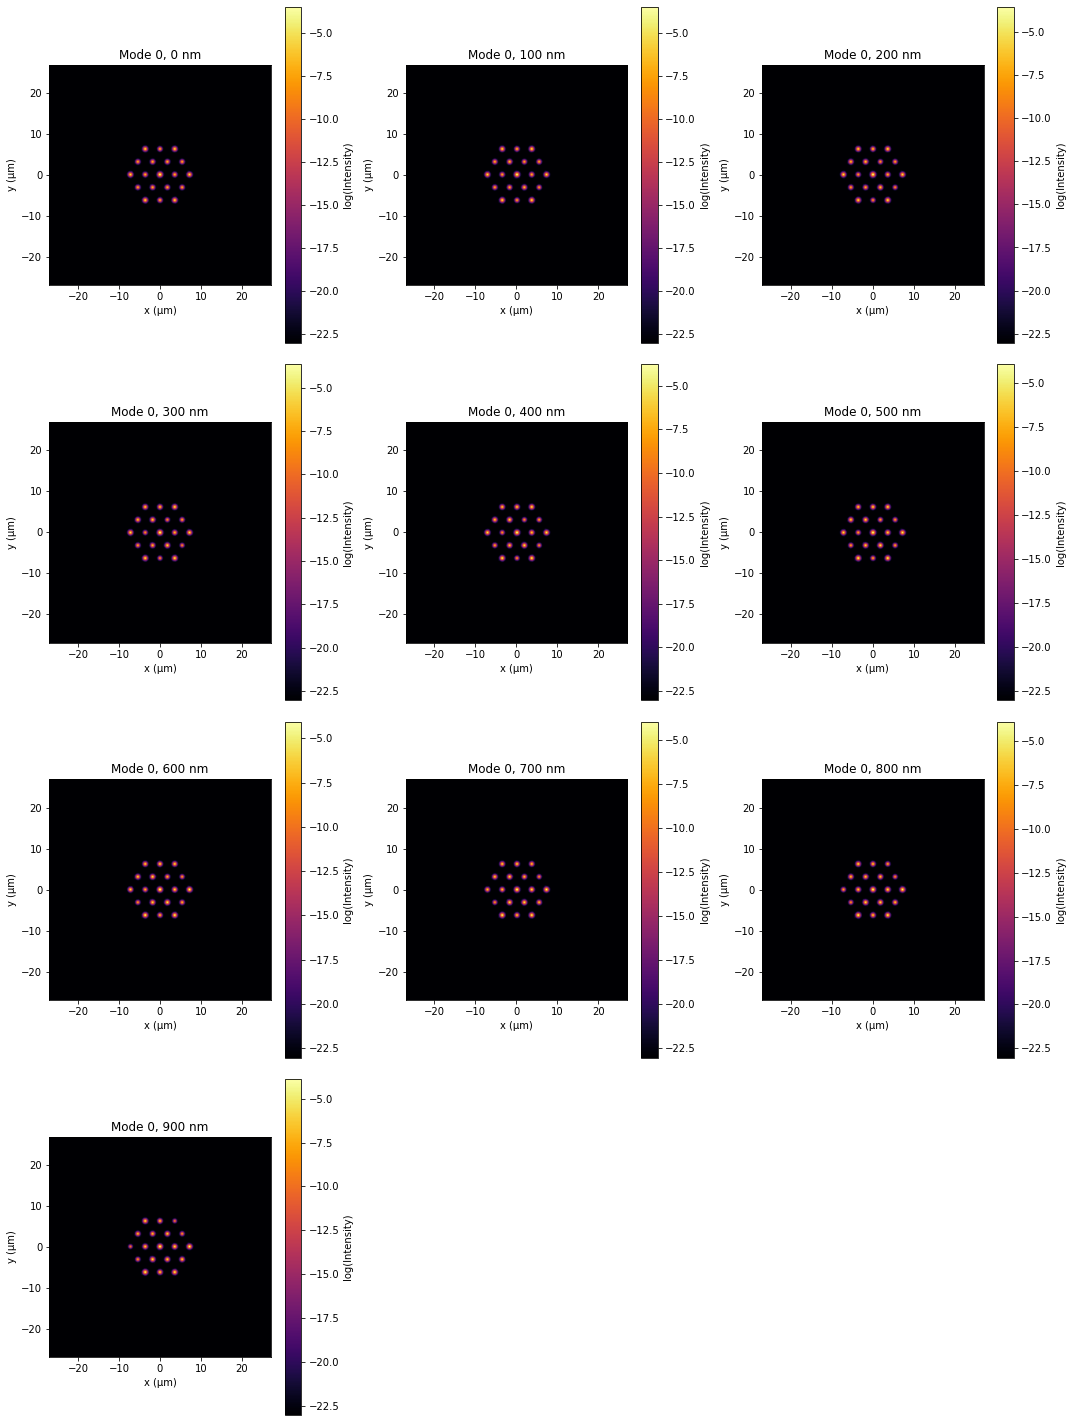

In [11]:
# =====================================================================
# CELL 11: VISUALIZE BATCH OUTPUT
# =====================================================================

print("Generating visualization...\n")

# Create titles for each field
titles = [f"Mode {c['mode_idx']}, {c['amplitude_nm']:.0f} nm" 
          for c in aberration_configs]

# Visualize
visualize_batch_output(uf_2d_batch, X_plot, Y_plot, titles)

[Geometric Fit] Estimated physical core pitch: 3.599 µm
[Geometric Fit] Residual matching RMS error: 1.0316e-01


GEOMETRIC HEX SIGNAL EXTRACTION PROCESSING
Processing core integration tracks for: Mode 0 | 0 nm...
Displaying Core Matrix for: Mode 0 | 0 nm


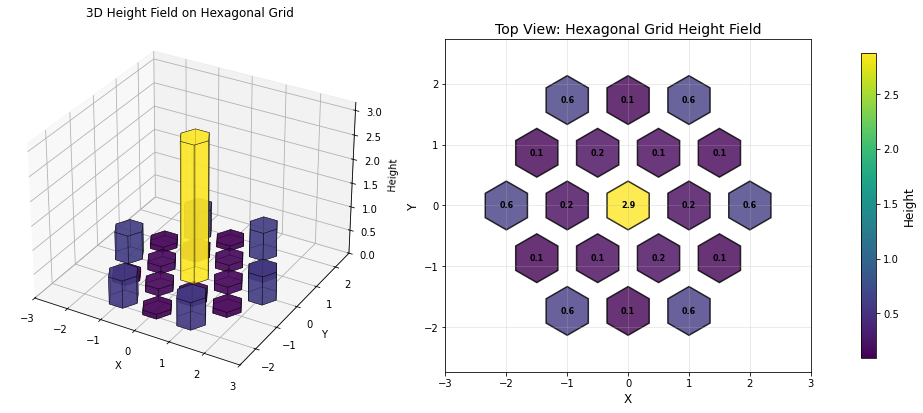

Processing core integration tracks for: Mode 0 | 100 nm...
Displaying Core Matrix for: Mode 0 | 100 nm


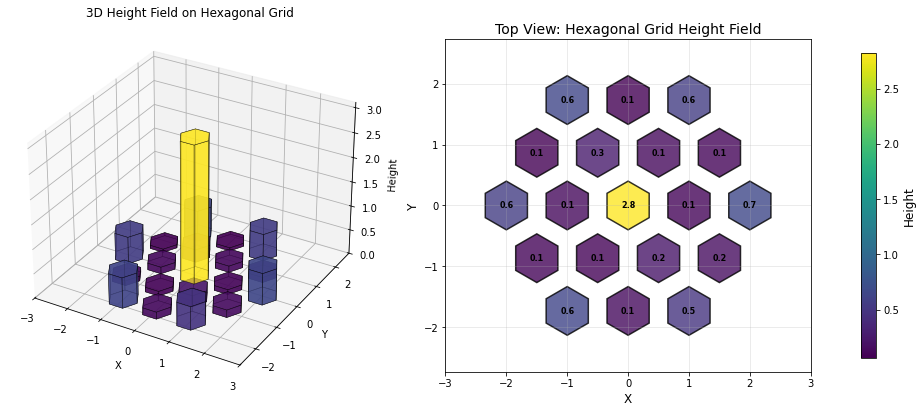

Processing core integration tracks for: Mode 0 | 200 nm...
Displaying Core Matrix for: Mode 0 | 200 nm


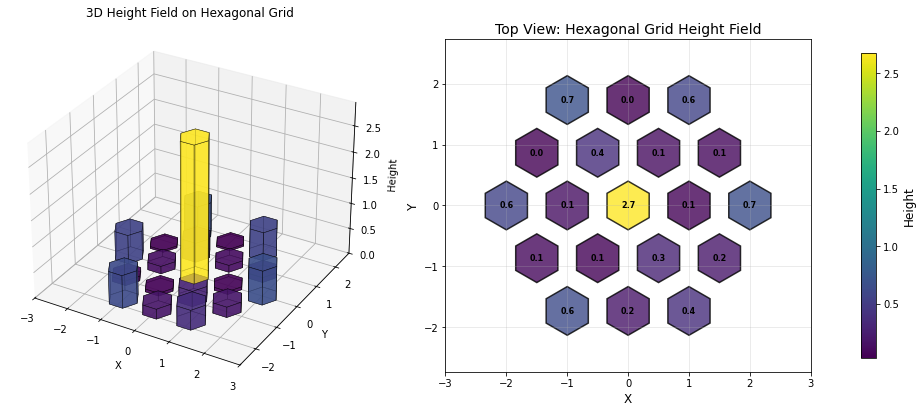

Processing core integration tracks for: Mode 0 | 300 nm...
Displaying Core Matrix for: Mode 0 | 300 nm


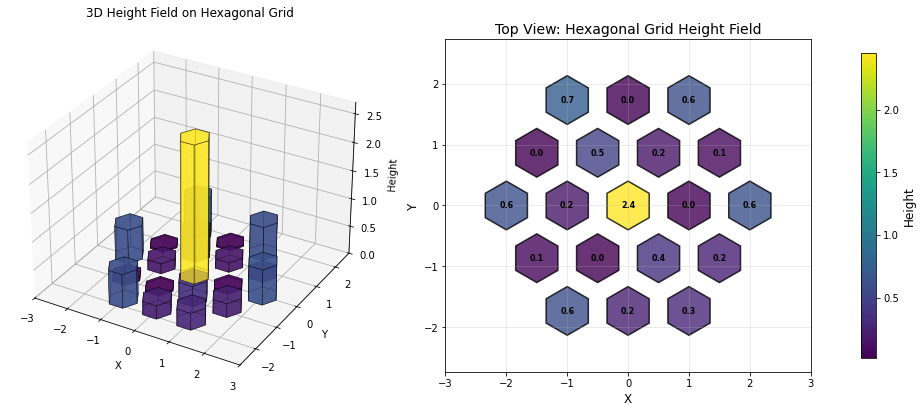

Processing core integration tracks for: Mode 0 | 400 nm...
Displaying Core Matrix for: Mode 0 | 400 nm


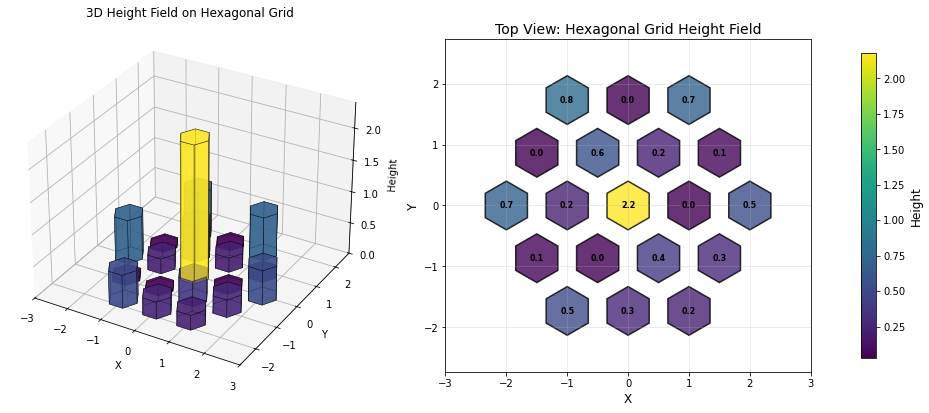

Processing core integration tracks for: Mode 0 | 500 nm...
Displaying Core Matrix for: Mode 0 | 500 nm


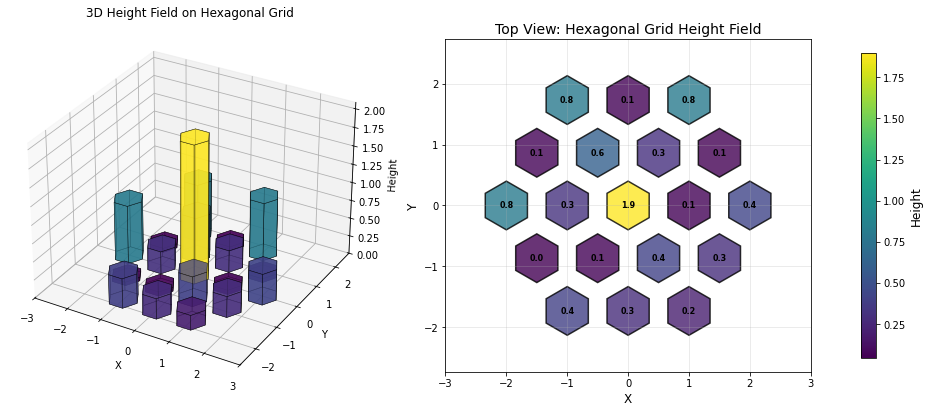

Processing core integration tracks for: Mode 0 | 600 nm...
Displaying Core Matrix for: Mode 0 | 600 nm


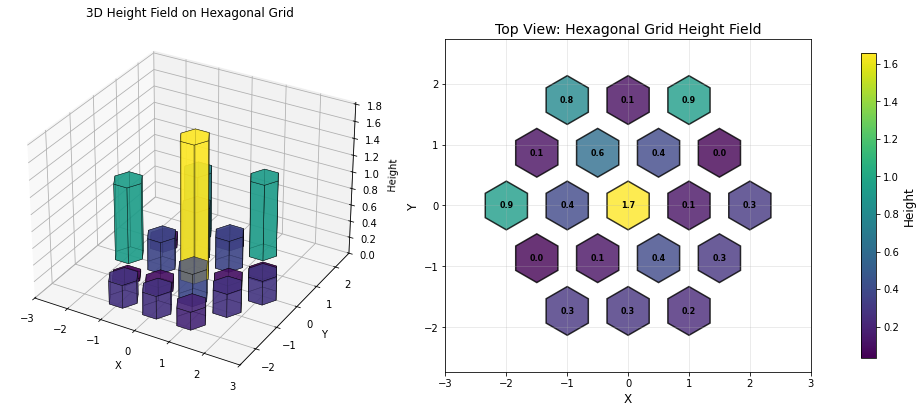

Processing core integration tracks for: Mode 0 | 700 nm...
Displaying Core Matrix for: Mode 0 | 700 nm


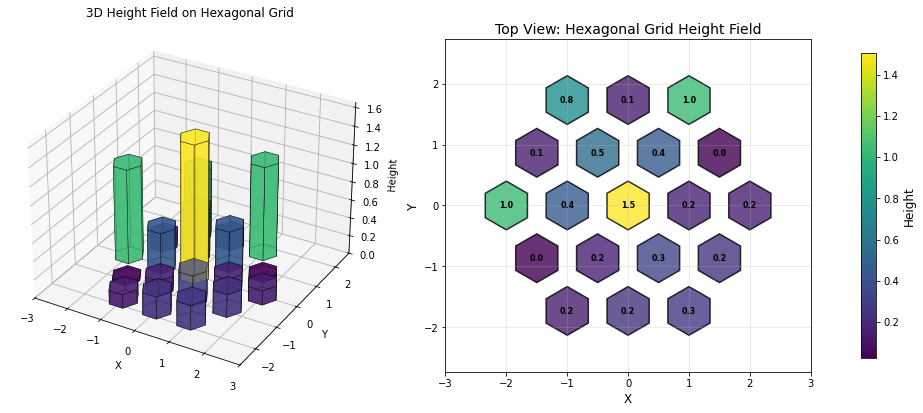

Processing core integration tracks for: Mode 0 | 800 nm...
Displaying Core Matrix for: Mode 0 | 800 nm


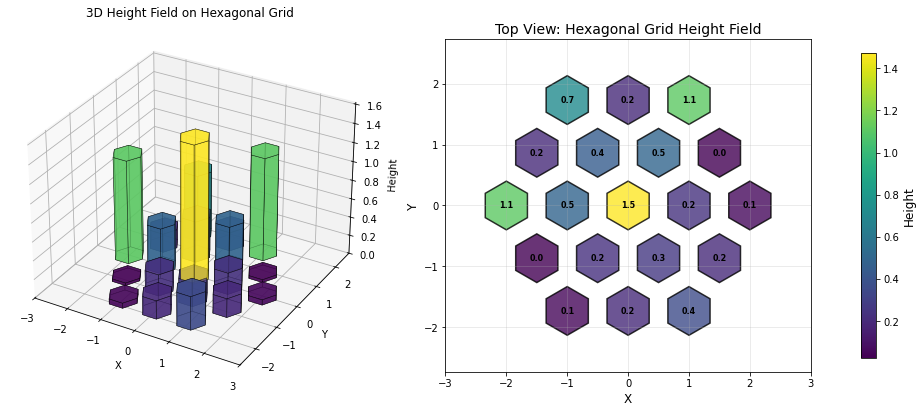

Processing core integration tracks for: Mode 0 | 900 nm...
Displaying Core Matrix for: Mode 0 | 900 nm


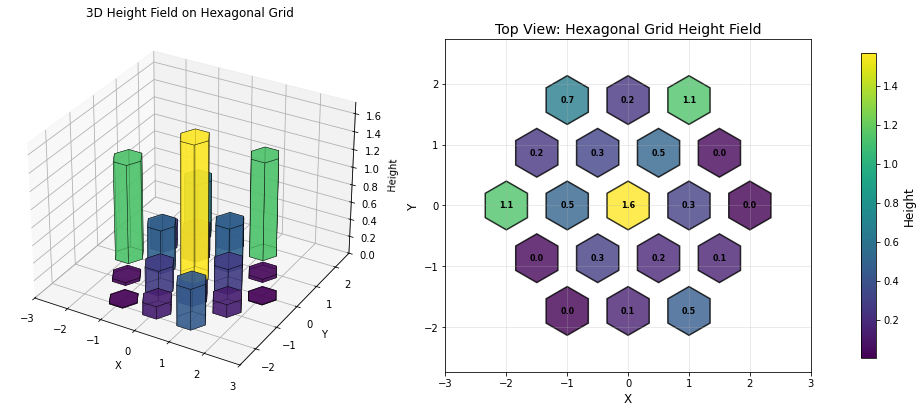

In [12]:
# Build titles corresponding to our simulated aberration cube configurations
titles = [f"Mode {c['mode_idx']} | {c['amplitude_nm']:.0f} nm" for c in aberration_configs]
ideal_grid_positions = [
    (0.0000, 0.0000), (1.0000, 0.0000), (0.5000, 0.8660), (-0.5000, 0.8660),
    (-1.0000, 0.0000), (-0.5000, -0.8660), (0.5000, -0.8660), (2.0000, 0.0000),
    (1.5000, 0.8660), (1.0000, 1.7321), (0.0000, 1.7321), (-1.0000, 1.7321),
    (-1.5000, 0.8660), (-2.0000, 0.0000), (-1.5000, -0.8660), (-1.0000, -1.7321),
    (0.0000, -1.7321), (1.0000, -1.7321), (1.5000, -0.8660)
]
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import maximum_filter, map_coordinates
from scipy.optimize import linear_sum_assignment
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import RegularPolygon

def calibrate_subpixel_centers(waveguide_modes_final, mesh_final):
    """Finds core centers to sub-pixel accuracy using a center-of-mass centroid approach."""
    plot_x_out = np.linspace(mesh_final.points[:, 0].min(), mesh_final.points[:, 0].max(), 400)
    plot_y_out = np.linspace(mesh_final.points[:, 1].min(), mesh_final.points[:, 1].max(), 400)
    X_plot_out, Y_plot_out = np.meshgrid(plot_x_out, plot_y_out)
    
    dx = plot_x_out[1] - plot_x_out[0]
    dy = plot_y_out[1] - plot_y_out[0]
    
    total_modes_profile = np.sum(np.abs(waveguide_modes_final)**2, axis=0)
    total_modes_2d = griddata(
        (mesh_final.points[:, 0], mesh_final.points[:, 1]), total_modes_profile, 
        (X_plot_out, Y_plot_out), method='linear', fill_value=0.0
    )
    
    is_peak = (total_modes_2d == maximum_filter(total_modes_2d, size=21)) & (total_modes_2d > 0.1 * np.max(total_modes_2d))
    peak_rows, peak_cols = np.where(is_peak)
    
    core_centers = []
    centroid_half_width = 4
    
    for r, c in zip(peak_rows, peak_cols):
        r_min, r_max = max(0, r - centroid_half_width), min(total_modes_2d.shape[0], r + centroid_half_width + 1)
        c_min, c_max = max(0, c - centroid_half_width), min(total_modes_2d.shape[1], c + centroid_half_width + 1)
        
        patch = total_modes_2d[r_min:r_max, c_min:c_max]
        r_indices, c_indices = np.meshgrid(np.arange(r_min, r_max), np.arange(c_min, c_max), indexing='ij')
        
        patch_sum = np.sum(patch)
        if patch_sum > 0:
            sub_pixel_row = np.sum(r_indices * patch) / patch_sum
            sub_pixel_col = np.sum(c_indices * patch) / patch_sum
            cx = plot_x_out[0] + sub_pixel_col * dx
            cy = plot_y_out[0] + sub_pixel_row * dy
        else:
            cx, cy = plot_x_out[c], plot_y_out[r]
            
        core_centers.append((cx, cy))
        
    return sorted(core_centers, key=lambda p: (np.round(p[1], 2), np.round(p[0], 2))), plot_x_out, plot_y_out, dx, dy


def collect_subpixel_signals(image_2d, x_min, y_min, dx, dy, centers, n=7):
    """Extracts an n x n subimage centered on fractional continuous coordinates."""
    signals = np.zeros(len(centers))
    half_n = n // 2
    offsets = np.arange(-half_n, half_n + 1)
    
    for idx, (cx, cy) in enumerate(centers):
        f_col = (cx - x_min) / dx
        f_row = (cy - y_min) / dy
        
        sub_cols, sub_rows = np.meshgrid(f_col + offsets, f_row + offsets)
        coords = np.vstack((sub_rows.ravel(), sub_cols.ravel()))
        subimage_flat = map_coordinates(image_2d, coords, order=3, mode='constant', cval=0.0)
        signals[idx] = np.mean(subimage_flat)
        
    return signals


# =====================================================================
# 5. INTEGRITY GEOMETRIC ASSIGNMENT MATCHER (HUNGARIAN ALIGNMENT)
# =====================================================================
def map_evaluated_to_ideal_geometry(core_centers, ideal_centers_list):
    """Calculates optimal rigid alignment (Procrustes SVD) and assigns global indexes."""
    ideal_centers = np.array(ideal_centers_list)
    eval_centers = np.array(core_centers)
    
    ideal_centered = ideal_centers - np.mean(ideal_centers, axis=0)
    eval_centered = eval_centers - np.mean(eval_centers, axis=0)
    
    scale_ideal = np.sqrt(np.mean(np.sum(ideal_centered**2, axis=1)))
    scale_eval = np.sqrt(np.mean(np.sum(eval_centered**2, axis=1)))
    eval_scaled = eval_centered * (scale_ideal / scale_eval)
    
    H = np.dot(eval_scaled.T, ideal_centered)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)
    eval_aligned = np.dot(eval_scaled, R.T)
    
    diff = eval_aligned[:, np.newaxis, :] - ideal_centered[np.newaxis, :, :]
    cost_matrix = np.sqrt(np.sum(diff**2, axis=-1))
    eval_indices, ideal_permutation = linear_sum_assignment(cost_matrix)
    
    print(f"[Geometric Fit] Estimated physical core pitch: {scale_eval / scale_ideal:.3f} µm")
    print(f"[Geometric Fit] Residual matching RMS error: {np.mean(cost_matrix[eval_indices, ideal_permutation]):.4e}\n")
    
    return ideal_permutation

# =====================================================================
# 6. HIGH-LEVEL VISUALIZATION ENGINE
# =====================================================================
def display_hex_grid_plots(ideal_centers, standardized_signals):
    """Generates the concurrent side-by-side 3D column and 2D map views."""
    heights = standardized_signals * 1000
    centers = np.array(ideal_centers)
    hex_radius = 0.4
    
    vmin, vmax = heights.min(), heights.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.viridis
    
    min_x, max_x = centers[:, 0].min() - 1, centers[:, 0].max() + 1
    min_y, max_y = centers[:, 1].min() - 1, centers[:, 1].max() + 1
    
    def create_hexagon_vertices(cx, cy, r):
        angles = np.linspace(0, 2 * np.pi, 7)[:-1]
        return np.column_stack((cx + r * np.cos(angles), cy + r * np.sin(angles)))

    fig = plt.figure(figsize=(18, 8))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122)
    
    polys, colors_list, n_sides = [], [], 6
    for i, (x, y) in enumerate(centers):
        height = heights[i]
        color = cmap(norm(height))
        hex_vertices = create_hexagon_vertices(x, y, hex_radius)
        
        base_3d = np.column_stack((hex_vertices, np.zeros(n_sides)))
        top_3d = np.column_stack((hex_vertices, np.full(n_sides, height)))
        vertices_3d = np.vstack((base_3d, top_3d))
        
        polys.extend([vertices_3d[:n_sides], vertices_3d[n_sides:]])
        colors_list.extend([color, color])
        
        for j in range(n_sides):
            side_face = [vertices_3d[j], vertices_3d[(j+1)%n_sides], vertices_3d[(j+1)%n_sides + n_sides], vertices_3d[j + n_sides]]
            polys.append(side_face)
            colors_list.append(color)

    poly_collection = Poly3DCollection(polys, alpha=0.7, edgecolor='black', linewidth=0.5)
    poly_collection.set_facecolor(colors_list)
    ax1.add_collection3d(poly_collection)
    ax1.set_xlim(min_x, max_x); ax1.set_ylim(min_y, max_y); ax1.set_zlim(0, heights.max() * 1.1)
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Height')
    ax1.set_title('3D Height Field on Hexagonal Grid')
    
    for i, (x, y) in enumerate(centers):
        height = heights[i]
        hexagon = RegularPolygon((x, y), numVertices=6, radius=hex_radius, orientation=0,
                                 facecolor=cmap(norm(height)), edgecolor='black', linewidth=1.5, alpha=0.8)
        ax2.add_patch(hexagon)
        ax2.text(x, y, f'{height:.1f}', ha='center', va='center', fontsize=8, fontweight='bold')

    ax2.set_xlim(min_x, max_x); ax2.set_ylim(min_y, max_y); ax2.set_aspect('equal')
    ax2.set_xlabel('X', fontsize=12); ax2.set_ylabel('Y', fontsize=12)
    ax2.set_title('Top View: Hexagonal Grid Height Field', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=[ax1, ax2], pad=0.05, shrink=0.7).set_label('Height', fontsize=12)
    plt.show()

# Run the batch sub-pixel centroid track, integration capture, and geometric hex mapping
visualize_batch_hex_grid_signals(
    pipeline=pipeline,
    E_output_batch=E_output_batch[:10],
    ideal_grid_positions=ideal_grid_positions,               # From your earlier calibration cell
    calibrate_subpixel_centers=calibrate_subpixel_centers,   # Your tracking routine function
    collect_subpixel_signals=collect_subpixel_signals,       # Your signal capture function
    map_evaluated_to_ideal_geometry=map_evaluated_to_ideal_geometry, # Matrix permuter
    display_hex_grid_plots=display_hex_grid_plots,           # Visual layout helper
    titles=titles,
    grid_resolution=400
)

In [13]:
# =====================================================================
# CELL 12: BATCH STATISTICS AND ANALYSIS
# =====================================================================

print("\nComputing batch statistics...\n")

batch_statistics(uf_batch, titles)

# Additional analysis: Mode coupling
print("\n" + "="*60)
print("MODE COUPLING ANALYSIS")
print("="*60)

for i in [0, len(aberration_configs)//2, -1]:
    config = aberration_configs[i]
    mode_powers = np.abs(uf_batch[i])**2
    top_3_indices = np.argsort(mode_powers)[-3:][::-1]
    
    print(f"\n{titles[i]}:")
    print(f"  Top 3 output modes: {top_3_indices}")
    print(f"  Their powers: {mode_powers[top_3_indices]}")
    print(f"  Concentrated power: {np.sum(mode_powers[top_3_indices]):.4f}")


Computing batch statistics...


BATCH PROPAGATION STATISTICS

Mode 0 | 0 nm:
  Total Power: 0.9949
  Max Mode (idx): 12
  Max Mode Power: 0.3032
  Power in Top 3 Modes: 0.6368

Mode 0 | 100 nm:
  Total Power: 0.9949
  Max Mode (idx): 12
  Max Mode Power: 0.2667
  Power in Top 3 Modes: 0.6379

Mode 0 | 200 nm:
  Total Power: 0.9949
  Max Mode (idx): 12
  Max Mode Power: 0.2275
  Power in Top 3 Modes: 0.6184

Mode 0 | 300 nm:
  Total Power: 0.9949
  Max Mode (idx): 11
  Max Mode Power: 0.2215
  Power in Top 3 Modes: 0.5919

Mode 0 | 400 nm:
  Total Power: 0.9949
  Max Mode (idx): 11
  Max Mode Power: 0.2157
  Power in Top 3 Modes: 0.5537

Mode 0 | 500 nm:
  Total Power: 0.9949
  Max Mode (idx): 11
  Max Mode Power: 0.1935
  Power in Top 3 Modes: 0.5035

Mode 0 | 600 nm:
  Total Power: 0.9949
  Max Mode (idx): 11
  Max Mode Power: 0.1575
  Power in Top 3 Modes: 0.4490

Mode 0 | 700 nm:
  Total Power: 0.9949
  Max Mode (idx): 12
  Max Mode Power: 0.1702
  Power in Top 3 Modes: 0.4584

Mod

In [14]:
# =====================================================================
# CELL 13: EXTRACT AND ANALYZE SPECIFIC METRICS
# =====================================================================

# Compute power in different mode groups
print("\n" + "="*60)
print("POWER DISTRIBUTION ANALYSIS")
print("="*60)

def analyze_power_distribution(uf_batch):
    """Analyze how power distributes among modes."""
    n_fields = uf_batch.shape[0]
    
    fundamental_power = np.abs(uf_batch[:, 0])**2
    top_3_power = np.sum(np.abs(uf_batch[:, :3])**2, axis=1)
    top_5_power = np.sum(np.abs(uf_batch[:, :5])**2, axis=1)
    total_power = np.sum(np.abs(uf_batch)**2, axis=1)
    
    return {
        'fundamental': fundamental_power,
        'top_3': top_3_power,
        'top_5': top_5_power,
        'total': total_power
    }

power_dist = analyze_power_distribution(uf_batch)

print(f"\nFundamental Mode Power:")
print(f"  Mean: {np.mean(power_dist['fundamental']):.4f}")
print(f"  Std: {np.std(power_dist['fundamental']):.4f}")
print(f"  Min: {np.min(power_dist['fundamental']):.4f}")
print(f"  Max: {np.max(power_dist['fundamental']):.4f}")

print(f"\nTop 3 Modes Power:")
print(f"  Mean: {np.mean(power_dist['top_3']):.4f}")
print(f"  Std: {np.std(power_dist['top_3']):.4f}")


POWER DISTRIBUTION ANALYSIS

Fundamental Mode Power:
  Mean: 0.0323
  Std: 0.0525
  Min: 0.0005
  Max: 0.3219

Top 3 Modes Power:
  Mean: 0.0705
  Std: 0.0670


In [15]:
# =====================================================================
# CELL 14: SAVE RESULTS FOR POST-PROCESSING
# =====================================================================

import pickle
from pathlib import Path

# Create results directory
results_dir = Path('batch_results')
results_dir.mkdir(exist_ok=True)

# Save data
results = {
    'u0_batch': u0_batch,
    'uf_batch': uf_batch,
    'E_output_batch': E_output_batch[:10],
    'uf_2d_batch': uf_2d_batch,
    'zs': zs,
    'us_batch': us_batch,
    'configs': aberration_configs,
    'X_plot': X_plot,
    'Y_plot': Y_plot
}

# Save as pickle
with open(results_dir / 'batch_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Also save numpy arrays separately for easier access
np.save(results_dir / 'u0_batch.npy', u0_batch)
np.save(results_dir / 'uf_batch.npy', uf_batch)
np.save(results_dir / 'uf_2d_batch.npy', uf_2d_batch)

print(f"Results saved to {results_dir}/")
print(f"  - batch_results.pkl (complete results)")
print(f"  - u0_batch.npy (input modal coefficients)")
print(f"  - uf_batch.npy (output modal coefficients)")
print(f"  - uf_2d_batch.npy (output intensity maps)")

Results saved to batch_results/
  - batch_results.pkl (complete results)
  - u0_batch.npy (input modal coefficients)
  - uf_batch.npy (output modal coefficients)
  - uf_2d_batch.npy (output intensity maps)


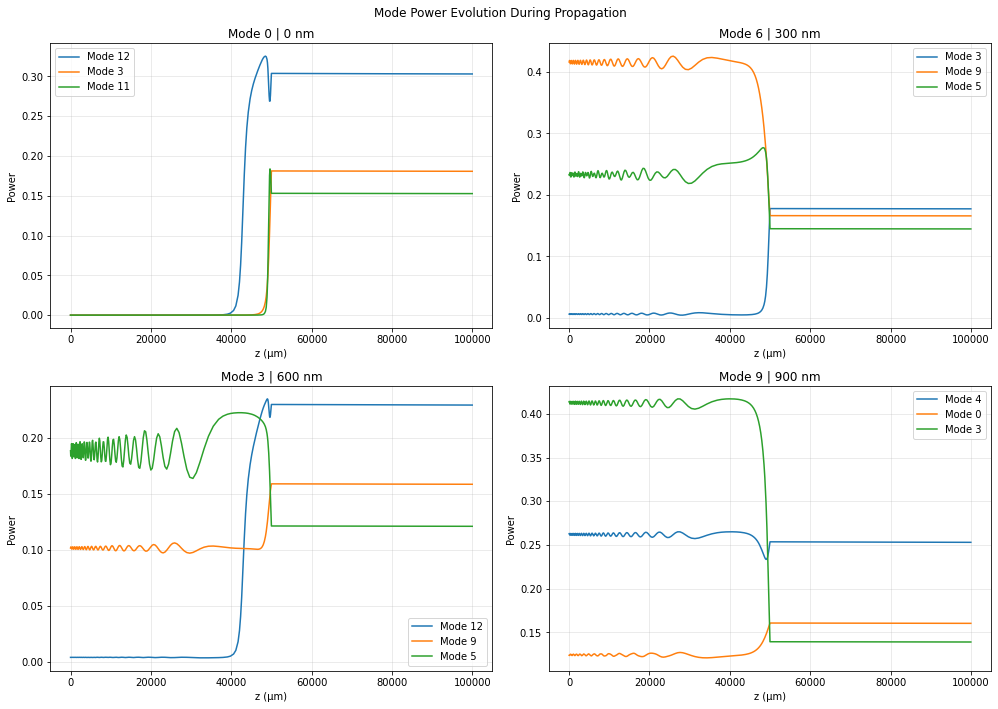

In [16]:
# =====================================================================
# CELL 15: MODE EVOLUTION ALONG PROPAGATION
# =====================================================================

# Analyze how modes evolve during propagation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select 4 representative fields
selected_indices = [0, len(aberration_configs)//3, 2*len(aberration_configs)//3, -1]

for ax, idx in zip(axes.flat, selected_indices):
    # us_batch shape: (n_fields, n_z, n_modes)
    # We want the evolution of the top 3 modes for field idx
    
    evolution = us_batch[idx]  # shape: (n_z, n_modes)
    
    # Find top 3 output modes
    output_powers = np.abs(uf_batch[idx])**2
    top_modes = np.argsort(output_powers)[-3:][::-1]
    
    # Plot evolution
    for mode_idx in top_modes:
        mode_evolution = np.abs(evolution[:, mode_idx])**2
        ax.plot(zs, mode_evolution, label=f'Mode {mode_idx}')
    
    ax.set_xlabel('z (μm)')
    ax.set_ylabel('Power')
    ax.set_title(titles[idx])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Mode Power Evolution During Propagation')
plt.tight_layout()
plt.show()

In [17]:
# =====================================================================
# CELL 16: EXPORT TO HDF5 FOR EXTERNAL ANALYSIS
# =====================================================================

try:
    import h5py
    
    filename = results_dir / 'batch_results.h5'
    
    with h5py.File(filename, 'w') as f:
        # Input/output modal coefficients
        f.create_dataset('u0_batch', data=u0_batch)
        f.create_dataset('uf_batch', data=uf_batch)
        
        # Evolution
        f.create_dataset('zs', data=zs)
        f.create_dataset('us_batch', data=us_batch)
        
        # Grid data
        f.create_dataset('X_plot', data=X_plot)
        f.create_dataset('Y_plot', data=Y_plot)
        f.create_dataset('uf_2d_batch', data=uf_2d_batch)
        
        # Metadata
        f.attrs['n_fields'] = len(aberration_configs)
        f.attrs['n_modes'] = uf_batch.shape[1]
        f.attrs['n_z_points'] = len(zs)
        f.attrs['wavelength_um'] = p['wl']
        f.attrs['lantern_length_um'] = p['z_ex']
    
    print(f"HDF5 file saved: {filename}")
except ImportError:
    print("h5py not installed. Skipping HDF5 export.")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject